In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import anndata as ad

from XvP_utils.plotting import processing

PROJECT_DIR = processing.find_repo_root()

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
TECHS = ['10x', 'polyT', 'randO', 'parse']
COLORS = {
    '10x':   '#4C72B0',
    'polyT': '#DD8452',
    'randO': '#C44E52',
    'parse': '#55A868',
}
TECH_LABELS = {
    '10x':   '10X Genomics',
    'polyT': "Parse 3'",
    'randO': 'Parse Random Oligo',
    'parse': 'Parse (combined)',
}

TISSUE_COLORS = {
    'Cancer':      "#b22104",
    'PBMC':        "#04385E",
    'Thymocytes':  "#6c4801",
    'K562/mESC':   "#49025F",
}

# Genes extracted pre- and post-filter during the main loading pass
GENES_TO_TRACK = ['HBB', 'HBA1', 'HBA2']

# Filtered AnnData cache — avoids re-reading h5ad files for downstream plots
CACHE_DIR = PROJECT_DIR / 'Data' / '.cache'
CACHE_DIR.mkdir(exist_ok=True)

In [ ]:
SAMPLES = [
    {
        'label': 'Exp 1',  'analysis': 'Analysis_6',
        'species': 'human', 'tissue': 'Cancer',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
    },
    {
        'label': 'Exp 2a', 'analysis': 'Analysis_3',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x_H1', 'parse_assay': 'parse_H1',
        'tenx_type': '',
    },
    {
        'label': 'Exp 2b', 'analysis': 'Analysis_3',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x_H2', 'parse_assay': 'parse_H2',
        'tenx_type': '',
    },
    {
        'label': 'Exp 3',  'analysis': 'Analysis_5',
        'species': 'human', 'tissue': 'PBMC',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
    },
    # {
    #     'label': 'Exp 4',  'analysis': 'Analysis_7',
    #     'species': 'human', 'tissue': 'PBMC',
    #     'tenx_assay': '10x',    'parse_assay': 'parse',
    #     'tenx_type': '',
    #     'cutoffs': {'10x': 2000, 'polyT': 900, 'randO': 900, 'parse': 900},
    # },
    {
        'label': 'Exp 4a', 'analysis': 'Analysis_2',
        'species': 'mouse', 'tissue': 'Thymocytes',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': 'standard',
    },
    {
        'label': 'Exp 4b', 'analysis': 'Analysis_2',
        'species': 'mouse', 'tissue': 'Thymocytes',
        'tenx_assay': '10x',    'parse_assay': 'parse_mini',
        'tenx_type': 'mini',
    },
    {
        'label': 'Exp 5',  'analysis': 'Analysis_4',
        'species': 'human_mouse', 'tissue': 'K562/mESC',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
    },
]

# Knee-plot cutoffs come from Config/notebooks.yaml (single source of truth),
# keyed by (analysis, variant): Analysis_2 uses its tenx_type (standard/mini),
# Analysis_3 uses the H1/H2 sample in the assay name, the rest have no variant.
def _variant(s):
    if s['analysis'] == 'Analysis_2':
        return s['tenx_type']
    if s['analysis'] == 'Analysis_3':
        return s['parse_assay'].rsplit('_', 1)[-1]
    return None

for _s in SAMPLES:
    _ctx = processing.notebook_context(_s['analysis'], _variant(_s))
    _s['cutoffs'] = {t: _ctx.knee('sampled', [t])[0] for t in TECHS}


In [5]:
def _norm_index(adata):
    """Build {normalized_name: [original_var_names]} using processing orthologs."""
    orthologs = processing._load_orthologs()
    index = {}
    for g in adata.var_names:
        norm = processing._normalize_gene_name(g, orthologs)
        index.setdefault(norm, []).append(g)
    return index


def _resolve_genes(adata, gene_set, norm_idx):
    """Return list of var_names that match gene_set (list or callable on normalized names)."""
    if callable(gene_set):
        return [orig for norm, origs in norm_idx.items() if gene_set(norm) for orig in origs]
    targets = {processing._normalize_gene_name(g, processing._load_orthologs()) for g in gene_set}
    return [orig for t in targets for orig in norm_idx.get(t, [])]


def _extract_gene_counts(d, genes_to_track, norm_idx):
    """Per-cell summed counts for each gene in genes_to_track, using ortholog-normalized lookup."""
    result = {}
    for gene in genes_to_track:
        present = _resolve_genes(d, [gene], norm_idx)
        result[gene] = (np.asarray(d[:, present].X.sum(axis=1)).flatten()
                        if present else np.zeros(d.n_obs, dtype=np.float64))
    return result


def extract_cell_metrics(adata, norm_idx):
    """Per-cell percentage DataFrame; MALAT1 is resolved via ortholog normalization."""
    present = _resolve_genes(adata, ['MALAT1'], norm_idx)
    malat1_counts = (np.asarray(adata[:, present].X.sum(axis=1)).flatten()
                     if present else np.zeros(adata.n_obs))
    percent_malat1 = malat1_counts / adata.obs['n_counts'].values * 100
    return pd.DataFrame({
        'percent_nascent': adata.obs['percent_nascent'].values,
        'percent_malat1':  percent_malat1,
        'percent_mito':    adata.obs['percent_mito'].values,
        'percent_ribo':    adata.obs['percent_ribo'].values,
        'percent_oxphos':  adata.obs['percent_oxphos'].values,
        'percent_lnc':     adata.obs['percent_lnc'].values,
        'percent_pc':      adata.obs['percent_pc'].values,
    })


def read_barcode_stats(star_dir, data_name):
    bc_path = star_dir / f'{data_name}_Solo.out' / 'Barcodes.stats'
    bc_stats = {}
    with open(bc_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                bc_stats[parts[0]] = int(parts[1])
    total = sum(bc_stats.values())
    valid = sum(v for k, v in bc_stats.items() if k.startswith('yes'))
    return bc_stats, valid / total * 100 if total > 0 else 0


def load_sample(sample, genes_to_track=None):
    label    = sample['label']
    analysis = sample['analysis']
    species  = sample['species']

    gene_info = pd.read_csv(
        PROJECT_DIR / 'Notebooks' / 'gene_info' / species / 'gene_attributes.csv',
        index_col=0
    )

    dfs, stat_rows, pseudobulk, gene_data = [], [], {}, {}
    for tech, data_name, assay, use_modified, tenx_type in [
        ('10x',   '10x',   sample['tenx_assay'],  False, sample['tenx_type']),
        ('polyT', 'polyT', sample['parse_assay'], False, ''),
        ('randO', 'randO', sample['parse_assay'], False, ''),
        ('parse', 'parse', sample['parse_assay'], True,  ''),
    ]:
        d = processing.init_processing(
            analysis_name=analysis, project_dir=PROJECT_DIR,
            data_name=data_name, assay=assay,
            data_title=f'{label} {tech}',
            type=tenx_type, modified=use_modified,
        )

        # Bulk-level stats on unfiltered data
        bulk_counts = np.asarray(d.X.sum(axis=0)).flatten()
        expressed = bulk_counts[bulk_counts > 0]
        props = expressed / expressed.sum()
        shannon = np.exp(-np.sum(props * np.log(props)))

        n_proc     = d.uns['n_processed']
        n_aligned  = d.uns['n_aligned']
        star_uniq  = d.uns['star_uniquely_mapped']
        star_multi = d.uns['star_multimapped']
        star_unmap = d.uns['star_unmapped']
        star_total = star_uniq + star_multi + star_unmap

        star_dir = PROJECT_DIR / 'Data' / analysis / assay / 'STARsolo'
        if tenx_type:
            star_dir = star_dir / tenx_type
        bc_stats, pct_valid_bc = read_barcode_stats(star_dir, data_name)

        row = {
            'sample': label, 'tech': tech,
            'kallisto_pct_unmapped': (n_proc - n_aligned) / n_proc * 100,
            'star_pct_unmapped':     star_unmap / star_total * 100,
            'star_pct_unique':       star_uniq  / star_total * 100,
            'n_genes_detected':      len(expressed),
            'shannon_entropy':       shannon,
            'star_pct_valid_bc':     pct_valid_bc,
        }
        for cat, count in bc_stats.items():
            row[f'bc_{cat}'] = count
        stat_rows.append(row)

        # Pre-filter gene counts (before UMI cutoff removes low-count cells)
        if genes_to_track:
            norm_idx_pre = _norm_index(d)
            pre_counts = _extract_gene_counts(d, genes_to_track, norm_idx_pre)

        # Filter cells, annotate biotype metrics, cache to disk
        d = processing.refilter(d, min_counts=sample['cutoffs'][tech])
        processing.add_cell_metrics(d, gene_info)

        cache_path = CACHE_DIR / f"{analysis}_{assay}_{data_name}_{sample['cutoffs'][tech]}_filtered.h5ad"
        if not cache_path.exists():
            d.write_h5ad(cache_path)

        norm_idx = _norm_index(d)

        # Post-filter gene counts and stitch into gene_data
        if genes_to_track:
            post_counts = _extract_gene_counts(d, genes_to_track, norm_idx)
            gene_data[tech] = {g: {'pre': pre_counts[g], 'post': post_counts[g]}
                               for g in genes_to_track}

        df = extract_cell_metrics(d, norm_idx)
        df['label']  = f"{label}\n{tech}"
        df['sample'] = label
        df['tech']   = tech
        dfs.append(df)

        pseudobulk[tech] = d.var['normalized_counts'].copy()
        del d

    return pd.concat(dfs, ignore_index=True), stat_rows, pseudobulk, gene_data

In [6]:
all_dfs, all_stats = [], []
pseudobulk_data = {}
gene_count_data = {}
for s in SAMPLES:
    print(f"Loading {s['label']}...")
    sample_df, sample_stats, sample_pb, sample_genes = load_sample(s, genes_to_track=GENES_TO_TRACK)
    all_dfs.append(sample_df)
    all_stats.extend(sample_stats)
    pseudobulk_data[s['label']] = sample_pb
    gene_count_data[s['label']] = sample_genes

df = pd.concat(all_dfs, ignore_index=True)
stats_df = pd.DataFrame(all_stats)
print(f"Total cells: {len(df)}")

Loading Exp 1...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading Exp 2a...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading Exp 2b...


...

Loading Exp 4b...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading Exp 5...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Total cells: 378934


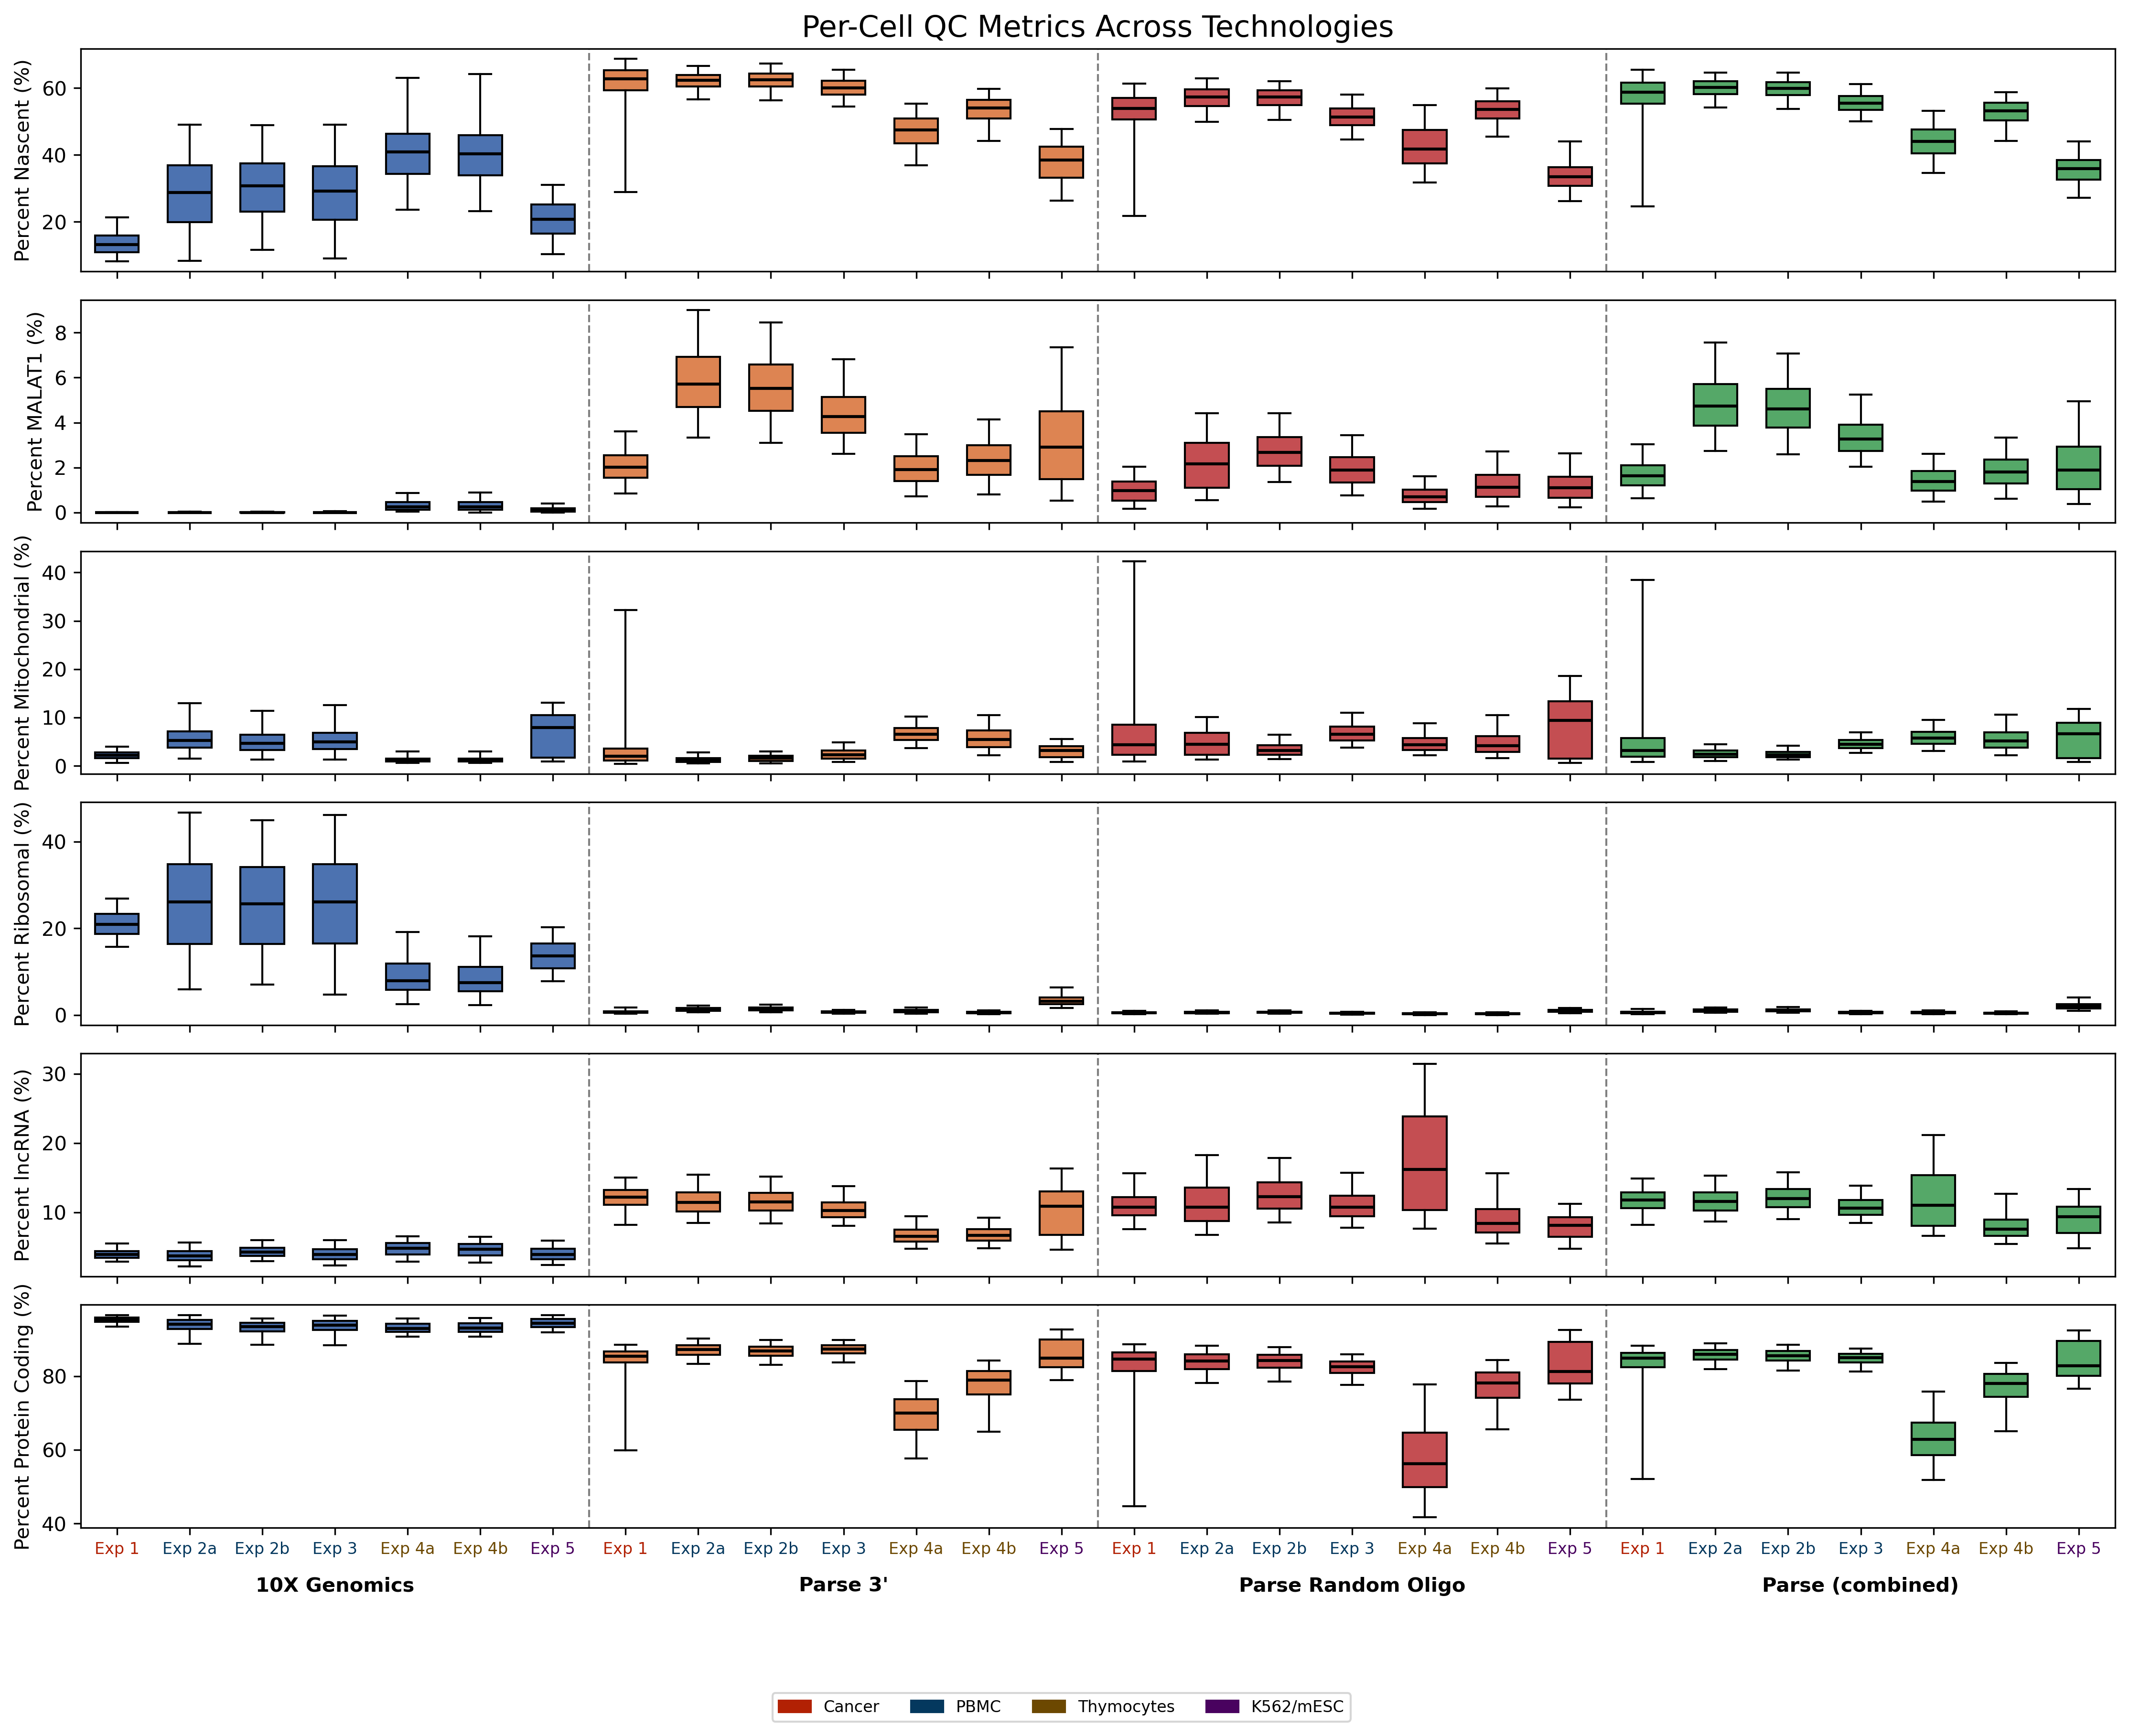

In [7]:
METRICS = [
    ('percent_nascent', 'Percent Nascent (%)'),
    ('percent_malat1',  'Percent MALAT1 (%)'),
    ('percent_mito',    'Percent Mitochondrial (%)'),
    ('percent_ribo',    'Percent Ribosomal (%)'),
    ('percent_lnc',     'Percent lncRNA (%)'),
    ('percent_pc',      'Percent Protein Coding (%)'),
]

# Group by technology: all samples for each tech together, 10x leftmost
n_samples = len(SAMPLES)
x_order = [f"{s['label']}\n{tech}" for tech in TECHS for s in SAMPLES]
display_labels = [s['label'] for tech in TECHS for s in SAMPLES]

fig, axes = plt.subplots(len(METRICS), 1, figsize=(15, 2 * len(METRICS)), sharex=True, dpi=300)

for ax, (metric, ylabel) in zip(axes, METRICS):
    data_by_label = [df.loc[df['label'] == lbl, metric].dropna().values for lbl in x_order]
    bp = ax.boxplot(
        data_by_label,
        positions=range(len(x_order)),
        patch_artist=True,
        showfliers=False,
        widths=0.6,
        whis=[5, 95],
        medianprops=dict(color='black', linewidth=1.5),
    )
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(COLORS[TECHS[i // n_samples]])

    for t in range(1, len(TECHS)):
        ax.axvline(x=t * n_samples - 0.5, color='gray', linestyle='--', linewidth=1)

    ax.set_ylabel(ylabel)

# Experiment name tick labels (no tech)
axes[-1].set_xticks(range(len(x_order)))
axes[-1].set_xticklabels(display_labels, fontsize=8)
for tick_idx, tick in enumerate(axes[-1].get_xticklabels()):
    tick.set_color(TISSUE_COLORS[SAMPLES[tick_idx % n_samples]['tissue']])

# Centered technology group labels below the tick labels
for t_idx, tech in enumerate(TECHS):
    center = t_idx * n_samples + (n_samples - 1) / 2
    axes[-1].text(center, -0.22, TECH_LABELS[tech], ha='center', va='top',
                  fontsize=10, fontweight='bold', color='black',
                  transform=axes[-1].get_xaxis_transform())

legend_handles = [mpatches.Patch(color=TISSUE_COLORS[t], label=t) for t in TISSUE_COLORS]
axes[0].set_title('Per-Cell QC Metrics Across Technologies', fontsize=15)

fig.subplots_adjust(bottom=0.12)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.legend(handles=legend_handles, loc='lower center', ncol=len(TISSUE_COLORS), fontsize=8, bbox_to_anchor=(0.5, -0.01))

plt.show()

In [8]:
rows = []
for tech in TECHS:
    for s in SAMPLES:
        lbl = f"{s['label']}\n{tech}"
        subset = df[df['label'] == lbl]
        for metric, metric_label in METRICS:
            vals = subset[metric].dropna()
            rows.append({
                'Experiment': s['label'],
                'Technology': TECH_LABELS[tech],
                'Metric': metric_label,
                'Mean': vals.mean(),
                'Min': vals.min(),
                'Max': vals.max(),
            })

summary_df = pd.DataFrame(rows)

for metric_label in summary_df['Metric'].unique():
    sub = summary_df[summary_df['Metric'] == metric_label].copy()
    sub = sub.drop(columns='Metric').set_index(['Experiment', 'Technology'])
    print(f"--- {metric_label} ---")
    display(sub.style.format({'Mean': '{:.2f}', 'Min': '{:.2f}', 'Max': '{:.2f}'}))

--- Percent Nascent (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,13.81,0.87,66.00
Exp 2a,10X Genomics,28.85,1.03,79.30
Exp 2b,10X Genomics,30.66,1.99,82.07
Exp 3,10X Genomics,29.14,0.74,80.76
Exp 4a,10X Genomics,40.70,1.96,77.30
Exp 4b,10X Genomics,40.43,1.54,78.54
Exp 5,10X Genomics,20.96,0.70,82.87
Exp 1,Parse 3',59.10,11.60,82.43
Exp 2a,Parse 3',62.01,39.11,75.93


--- Percent MALAT1 (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,0.00,0.00,0.12
Exp 2a,10X Genomics,0.01,0.00,0.19
Exp 2b,10X Genomics,0.01,0.00,0.21
Exp 3,10X Genomics,0.01,0.00,0.54
Exp 4a,10X Genomics,0.33,0.00,2.53
Exp 4b,10X Genomics,0.33,0.00,2.60
Exp 5,10X Genomics,0.13,0.00,1.22
Exp 1,Parse 3',2.11,0.00,12.77
Exp 2a,Parse 3',5.89,0.63,16.21


--- Percent Mitochondrial (%) ---


...

,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,21.03,1.57,39.15
Exp 2a,10X Genomics,25.97,0.00,65.92
Exp 2b,10X Genomics,25.52,0.16,63.23
Exp 3,10X Genomics,25.85,0.00,75.94
Exp 4a,10X Genomics,9.23,0.16,40.38
Exp 4b,10X Genomics,8.67,0.14,37.43
Exp 5,10X Genomics,13.71,0.38,36.11
Exp 1,Parse 3',0.78,0.00,8.54
Exp 2a,Parse 3',1.30,0.08,5.56


--- Percent lncRNA (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,3.99,1.13,16.91
Exp 2a,10X Genomics,3.81,0.19,18.32
Exp 2b,10X Genomics,4.37,0.61,17.10
Exp 3,10X Genomics,4.03,0.00,19.81
Exp 4a,10X Genomics,4.75,0.90,15.34
Exp 4b,10X Genomics,4.63,0.77,15.47
Exp 5,10X Genomics,4.03,0.95,30.84
Exp 1,Parse 3',12.02,2.52,24.46
Exp 2a,Parse 3',11.60,3.97,22.18


--- Percent Protein Coding (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,95.16,58.14,98.62
Exp 2a,10X Genomics,93.34,25.92,99.34
Exp 2b,10X Genomics,92.81,43.81,97.90
Exp 3,10X Genomics,93.07,25.70,99.40
Exp 4a,10X Genomics,93.01,72.92,98.77
Exp 4b,10X Genomics,93.13,70.48,98.90
Exp 5,10X Genomics,94.21,65.67,97.84
Exp 1,Parse 3',82.77,28.10,93.00
Exp 2a,Parse 3',86.97,64.08,93.85


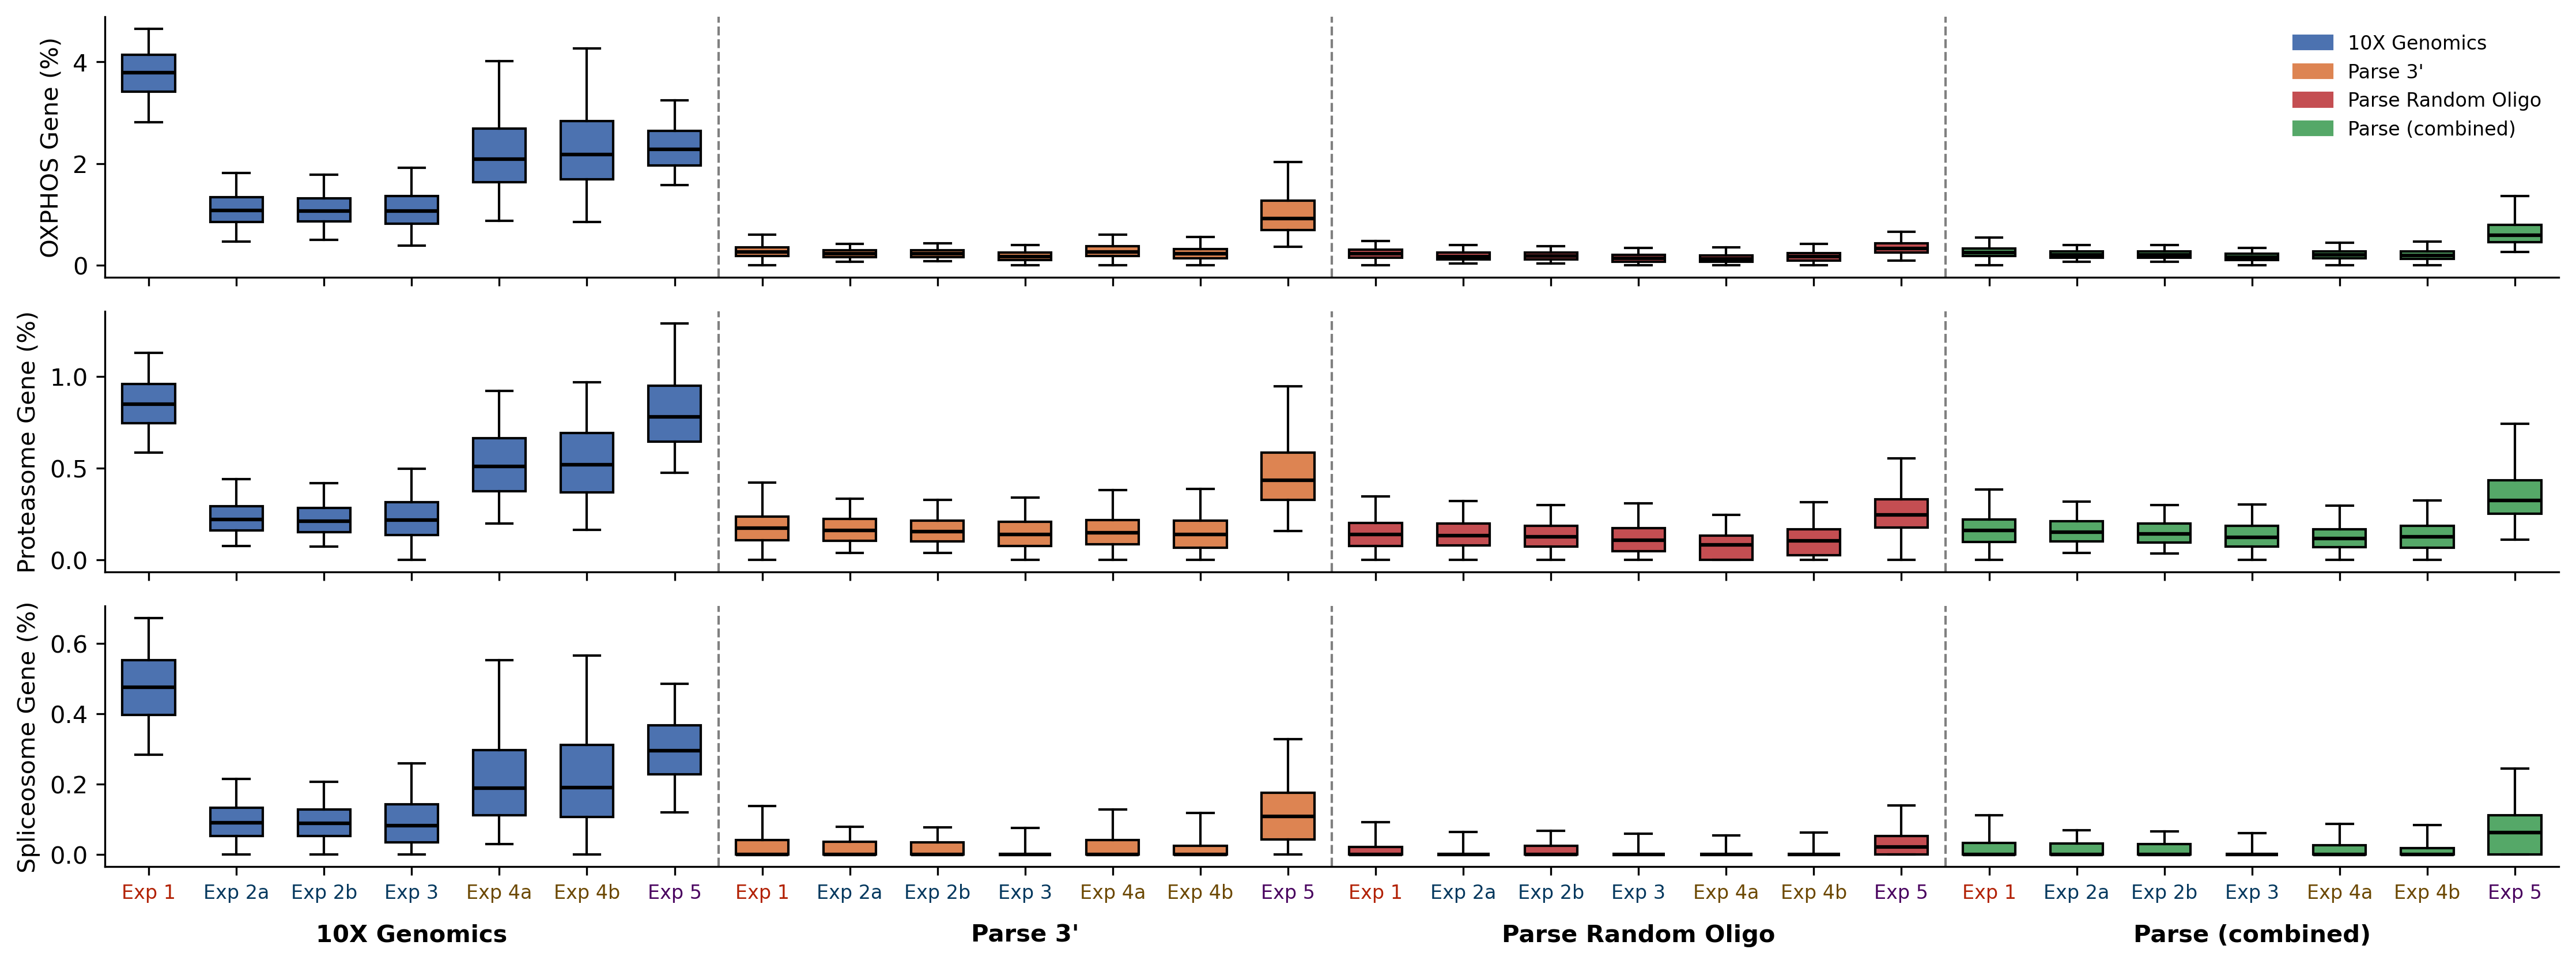

--- OXPHOS Gene (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,3.76,0.30,8.04
Exp 2a,10X Genomics,1.10,0.00,3.51
Exp 2b,10X Genomics,1.10,0.00,3.14
Exp 3,10X Genomics,1.10,0.00,4.10
Exp 4a,10X Genomics,2.22,0.00,7.51
Exp 4b,10X Genomics,2.32,0.00,8.11
Exp 5,10X Genomics,2.32,0.06,5.29
Exp 1,Parse 3',0.29,0.00,2.70
Exp 2a,Parse 3',0.23,0.00,0.84


--- Proteasome Gene (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,0.85,0.00,1.91
Exp 2a,10X Genomics,0.24,0.00,1.03
Exp 2b,10X Genomics,0.22,0.00,1.00
Exp 3,10X Genomics,0.23,0.00,1.25
Exp 4a,10X Genomics,0.53,0.00,1.69
Exp 4b,10X Genomics,0.54,0.00,1.78
Exp 5,10X Genomics,0.82,0.00,2.31
Exp 1,Parse 3',0.18,0.00,1.60
Exp 2a,Parse 3',0.17,0.00,0.74


--- Spliceosome Gene (%) ---


,,Mean,Min,Max
Experiment,Technology,,,
Exp 1,10X Genomics,0.48,0.00,1.10
Exp 2a,10X Genomics,0.10,0.00,0.57
Exp 2b,10X Genomics,0.10,0.00,0.59
Exp 3,10X Genomics,0.10,0.00,1.09
Exp 4a,10X Genomics,0.22,0.00,1.37
Exp 4b,10X Genomics,0.23,0.00,1.35
Exp 5,10X Genomics,0.30,0.00,0.91
Exp 1,Parse 3',0.03,0.00,0.90
Exp 2a,Parse 3',0.02,0.00,0.25


In [9]:
def plot_gene_set_boxplots(samples, gene_sets, figsize=None):
    """Plot per-cell % of counts from multiple gene sets, stacked like the QC boxplots.

    Gene names are matched via ortholog normalization so you can specify human
    canonical names (e.g. 'MALAT1', 'MT-ND1') and they will resolve correctly
    in mouse and human/mouse mixture datasets.

    Filtered AnnData objects are read from CACHE_DIR if available (populated by
    the main load_sample loop), or computed and cached on first use.

    Parameters
    ----------
    samples : list of sample dicts (same structure as SAMPLES)
    gene_sets : dict of {row_label: gene_set} where each gene_set is either
                a list of canonical gene names, or a callable (str -> bool)
                applied to normalized (human-uppercase) gene names —
                e.g. ``lambda g: g.startswith('MT-')``
    figsize : tuple, optional
    """
    rows = {name: [] for name in gene_sets}
    for sample in samples:
        label    = sample['label']
        analysis = sample['analysis']
        for tech, data_name, assay, use_modified, tenx_type in [
            ('10x',   '10x',   sample['tenx_assay'],  False, sample['tenx_type']),
            ('polyT', 'polyT', sample['parse_assay'], False, ''),
            ('randO', 'randO', sample['parse_assay'], False, ''),
            ('parse', 'parse', sample['parse_assay'], True,  ''),
        ]:
            cache_path = CACHE_DIR / f"{analysis}_{assay}_{data_name}_{sample['cutoffs'][tech]}_filtered.h5ad"
            if cache_path.exists():
                d = ad.read_h5ad(cache_path)
            else:
                d = processing.init_processing(
                    analysis_name=analysis, project_dir=PROJECT_DIR,
                    data_name=data_name, assay=assay,
                    data_title=f'{label} {tech}',
                    type=tenx_type, modified=use_modified,
                )
                d = processing.refilter(d, min_counts=sample['cutoffs'][tech])
                gene_info = pd.read_csv(
                    PROJECT_DIR / 'Notebooks' / 'gene_info' / sample['species'] / 'gene_attributes.csv',
                    index_col=0
                )
                processing.add_cell_metrics(d, gene_info)
                d.write_h5ad(cache_path)

            norm_idx = _norm_index(d)
            lbl      = f"{label}\n{tech}"
            n_counts = d.obs['n_counts'].values
            for name, gene_set in gene_sets.items():
                present = _resolve_genes(d, gene_set, norm_idx)
                gene_counts = (np.asarray(d[:, present].X.sum(axis=1)).flatten()
                               if present else np.zeros(d.n_obs))
                pct = gene_counts / n_counts * 100
                for v in pct:
                    rows[name].append({'label': lbl, 'pct': v})
            del d

    n_metrics = len(gene_sets)
    n_samples = len(samples)
    x_order   = [f"{s['label']}\n{tech}" for tech in TECHS for s in samples]

    fig, axes = plt.subplots(
        n_metrics, 1,
        figsize=figsize or (15, 2 * n_metrics),
        sharex=True, dpi=300,
    )
    axes = np.atleast_1d(axes)

    for ax, name in zip(axes, gene_sets):
        pct_df        = pd.DataFrame(rows[name])
        data_by_label = [pct_df.loc[pct_df['label'] == lbl, 'pct'].dropna().values
                         for lbl in x_order]
        bp = ax.boxplot(
            data_by_label,
            positions=range(len(x_order)),
            patch_artist=True,
            showfliers=False,
            widths=0.6,
            whis=[5, 95],
            medianprops=dict(color='black', linewidth=1.5),
        )
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(COLORS[TECHS[i // n_samples]])

        for t in range(1, len(TECHS)):
            ax.axvline(x=t * n_samples - 0.5, color='gray', linestyle='--', linewidth=1)

        ax.set_ylabel(name)
        ax.spines[['top', 'right']].set_visible(False)

    axes[-1].set_xticks(range(len(x_order)))
    axes[-1].set_xticklabels([s['label'] for tech in TECHS for s in samples], fontsize=8)
    for tick_idx, tick in enumerate(axes[-1].get_xticklabels()):
        tick.set_color(TISSUE_COLORS[samples[tick_idx % n_samples]['tissue']])

    for t_idx, tech in enumerate(TECHS):
        center = t_idx * n_samples + (n_samples - 1) / 2
        axes[-1].text(center, -0.22, TECH_LABELS[tech], ha='center', va='top',
                      fontsize=10, fontweight='bold', color='black',
                      transform=axes[-1].get_xaxis_transform())

    axes[0].legend(
        handles=[mpatches.Patch(color=COLORS[t], label=TECH_LABELS[t]) for t in TECHS],
        loc='upper right', frameon=False, fontsize=8,
    )
    fig.subplots_adjust(bottom=0.12)
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

    for name in gene_sets:
        pct_df = pd.DataFrame(rows[name])
        summary_rows = []
        for tech in TECHS:
            for s in samples:
                lbl  = f"{s['label']}\n{tech}"
                vals = pct_df.loc[pct_df['label'] == lbl, 'pct'].dropna()
                summary_rows.append({
                    'Experiment': s['label'],
                    'Technology': TECH_LABELS[tech],
                    'Mean': vals.mean(),
                    'Min':  vals.min(),
                    'Max':  vals.max(),
                })
        summary = pd.DataFrame(summary_rows).set_index(['Experiment', 'Technology'])
        print(f"--- {name} ---")
        display(summary.style.format('{:.2f}'))


plot_gene_set_boxplots(SAMPLES, {
    'OXPHOS Gene (%)':      lambda g: g.startswith("SDH") or g.startswith("UQCR") or g.startswith("COX") or g.startswith("NDUF") or g.startswith("ATP5"),
    'Proteasome Gene (%)':  lambda g: g.startswith('PSMA') or g.startswith('PSMB') or g.startswith('PSMC') or g.startswith('PSMD'),
    'Spliceosome Gene (%)': lambda g: g.startswith('SNRPB') or g.startswith('SNRPD') or g.startswith('SNRPE') or g.startswith('SNRPF') or g.startswith('SNRPG'),
})

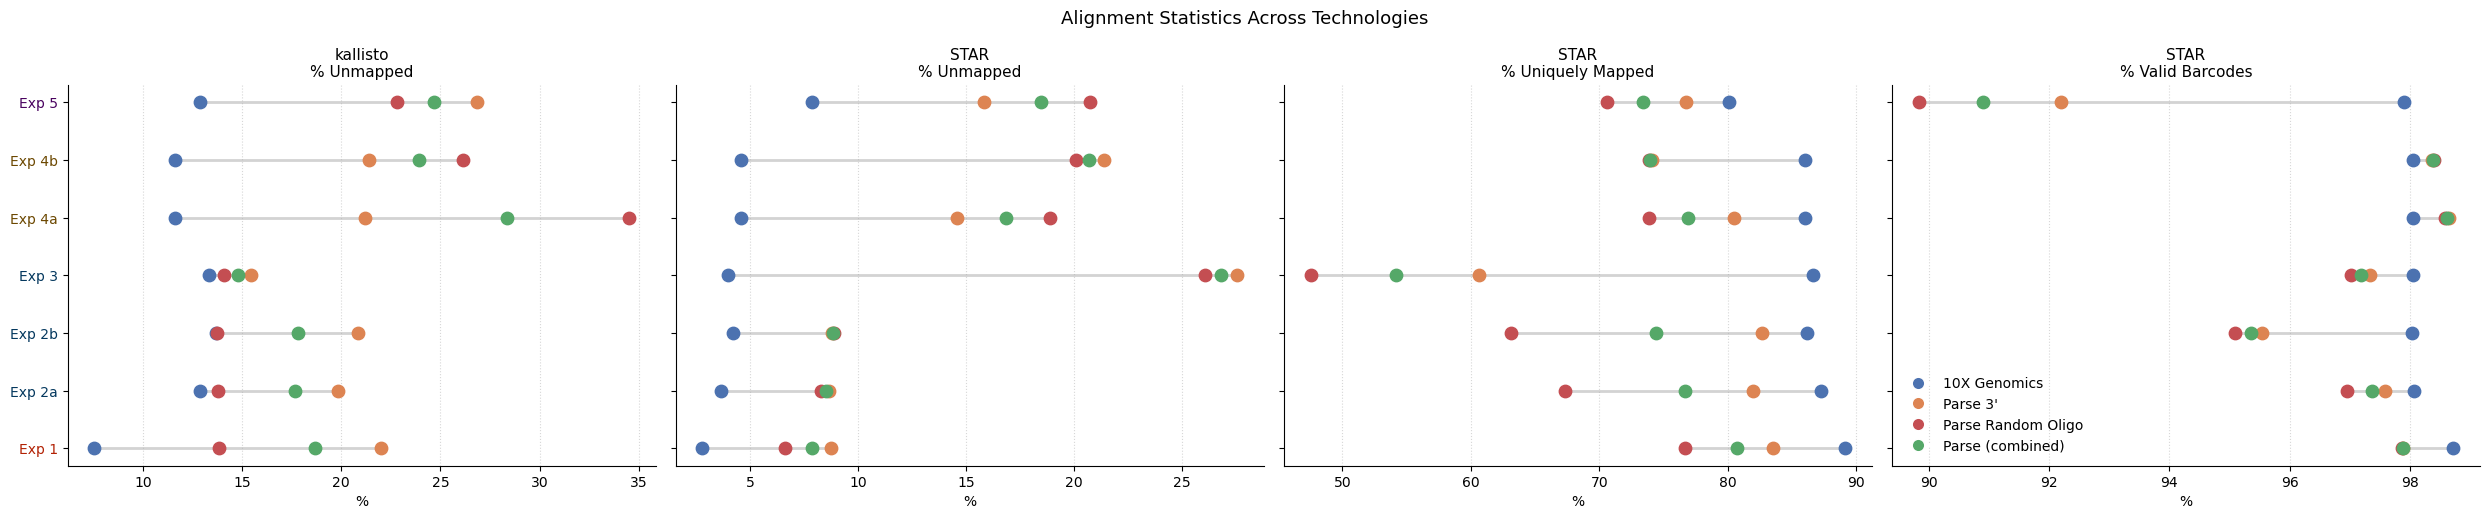

In [10]:
STAT_METRICS = [
    ('kallisto_pct_unmapped', 'kallisto\n% Unmapped'),
    ('star_pct_unmapped',     'STAR\n% Unmapped'),
    ('star_pct_unique',       'STAR\n% Uniquely Mapped'),
    ('star_pct_valid_bc',     'STAR\n% Valid Barcodes'),
]

sample_labels = [s['label'] for s in SAMPLES]

fig, axes = plt.subplots(1, len(STAT_METRICS), figsize=(25, max(4, len(sample_labels) * 0.75)), sharey=True)

for ax, (metric, title) in zip(axes, STAT_METRICS):
    for y, lbl in enumerate(sample_labels):
        sub  = stats_df[stats_df['sample'] == lbl]
        vals = {tech: sub.loc[sub['tech'] == tech, metric].values[0] for tech in TECHS}

        ax.plot([min(vals.values()), max(vals.values())], [y, y],
                color='lightgray', linewidth=2, zorder=1)
        for tech, val in vals.items():
            ax.scatter([val], [y], color=COLORS[tech], s=80, zorder=2)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('%')
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(range(len(sample_labels)))
axes[0].set_yticklabels(sample_labels)
for i, tick in enumerate(axes[0].get_yticklabels()):
    tick.set_color(TISSUE_COLORS[SAMPLES[i]['tissue']])

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[t],
               markersize=9, label=TECH_LABELS[t])
    for t in TECHS
]
axes[-1].legend(handles=legend_handles, loc='lower left', frameon=False)

fig.suptitle('Alignment Statistics Across Technologies', fontsize=13)
fig.tight_layout()
plt.show()

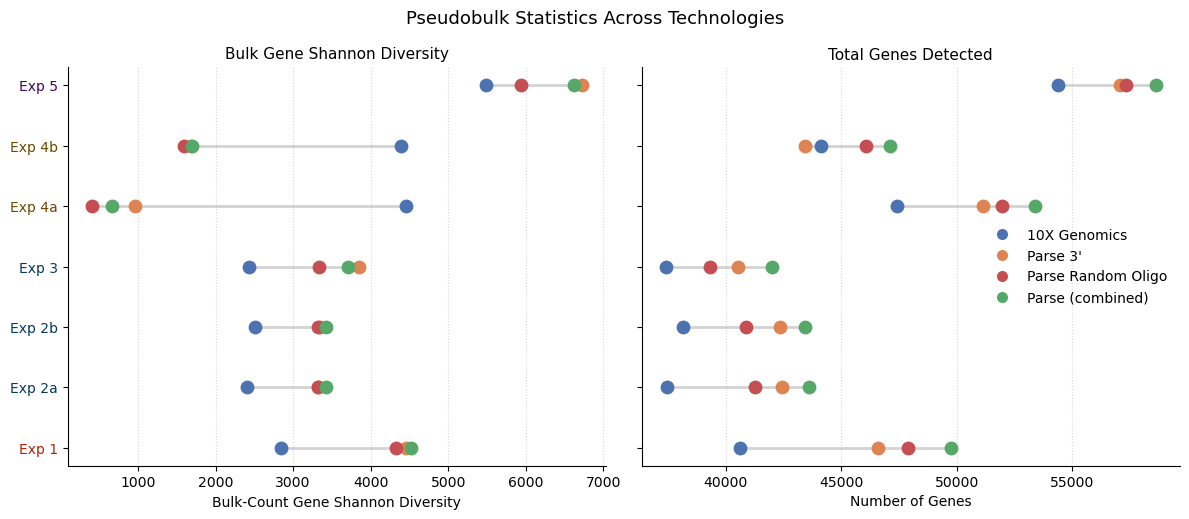

In [11]:
BULK_METRICS = [
    ('shannon_entropy',  'Bulk Gene Shannon Diversity'),
    ('n_genes_detected', 'Total Genes Detected'),
]

sample_labels = [s['label'] for s in SAMPLES]

fig, axes = plt.subplots(1, len(BULK_METRICS), figsize=(12, max(4, len(sample_labels) * 0.75)), sharey=True)

for ax, (metric, title) in zip(axes, BULK_METRICS):
    for y, lbl in enumerate(sample_labels):
        sub  = stats_df[stats_df['sample'] == lbl]
        vals = {tech: sub.loc[sub['tech'] == tech, metric].values[0] for tech in TECHS}

        ax.plot([min(vals.values()), max(vals.values())], [y, y],
                color='lightgray', linewidth=2, zorder=1)
        for tech, val in vals.items():
            ax.scatter([val], [y], color=COLORS[tech], s=80, zorder=2)

    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(range(len(sample_labels)))
axes[0].set_yticklabels(sample_labels)
for i, tick in enumerate(axes[0].get_yticklabels()):
    tick.set_color(TISSUE_COLORS[SAMPLES[i]['tissue']])

axes[0].set_xlabel("Bulk-Count Gene Shannon Diversity")
axes[1].set_xlabel("Number of Genes")

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[t],
               markersize=9, label=TECH_LABELS[t])
    for t in TECHS
]
axes[1].legend(handles=legend_handles, loc='center right', frameon=False)

fig.suptitle('Pseudobulk Statistics Across Technologies', fontsize=13)
fig.tight_layout()
plt.show()

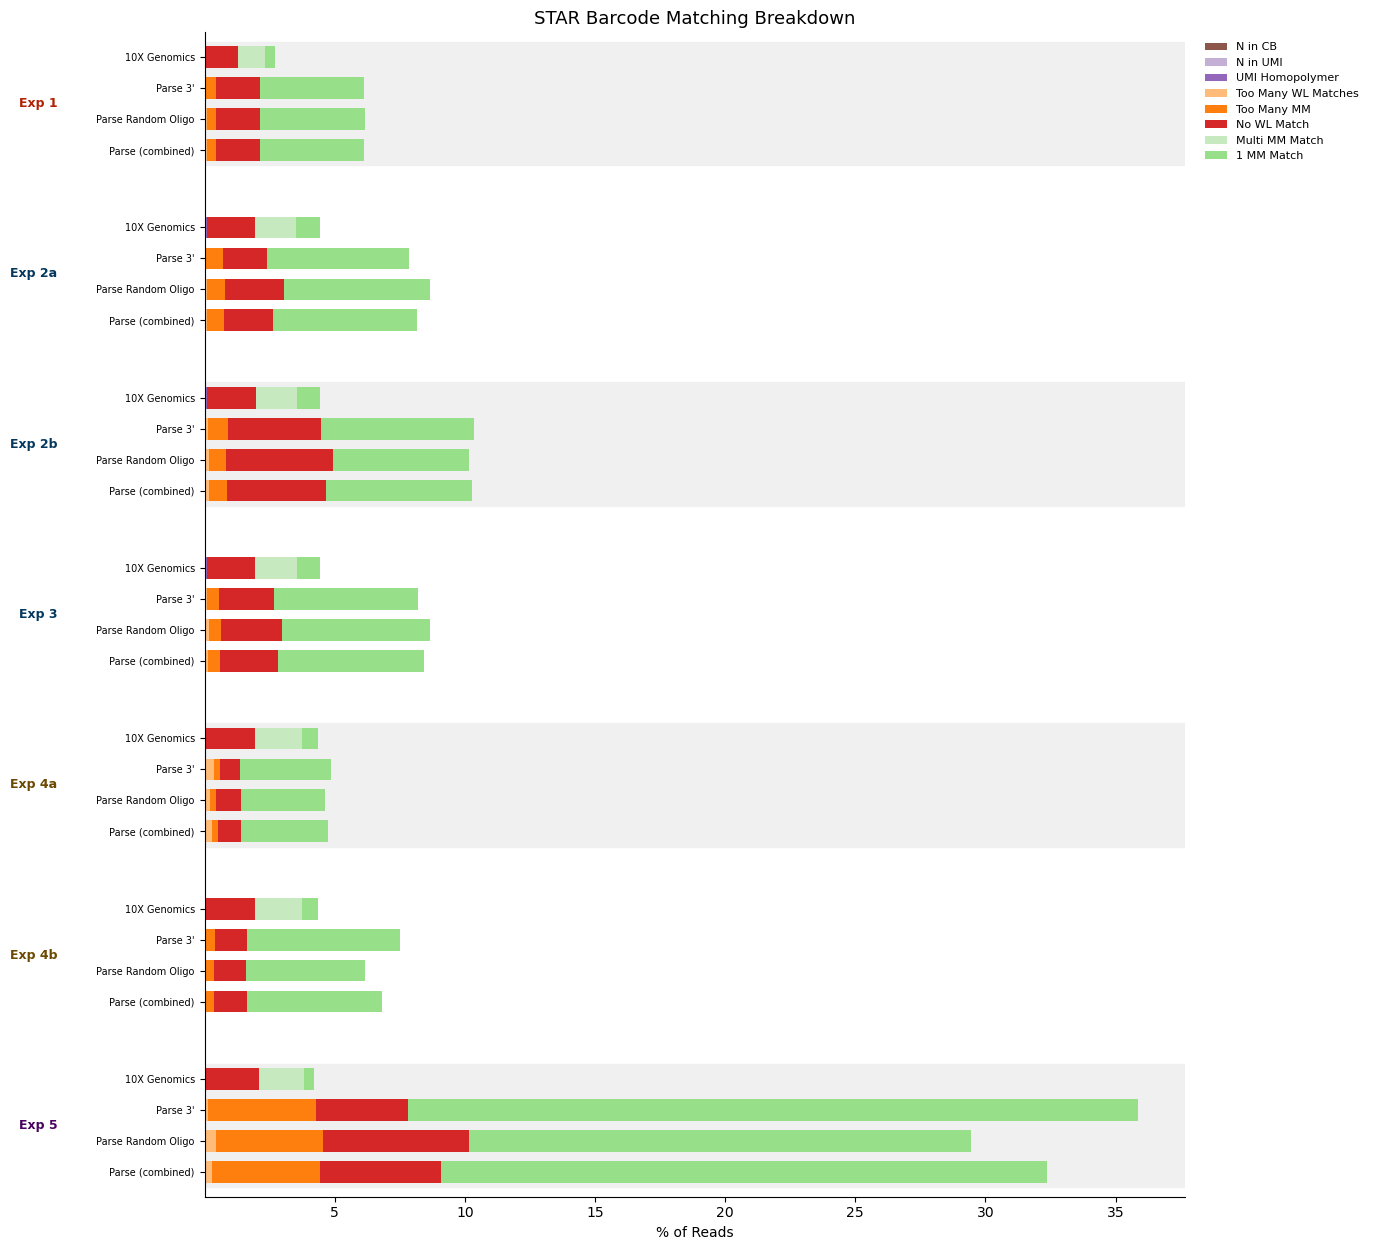

In [12]:
BC_CATEGORIES = [
    ('bc_yesWLmatchExact',      'Exact Match',           '#2ca02c'),
    ('bc_yesOneWLmatchWithMM',  '1 MM Match',            '#98df8a'),
    ('bc_yesMultWLmatchWithMM', 'Multi MM Match',        '#c7e9c0'),
    ('bc_noNoWLmatch',          'No WL Match',           '#d62728'),
    ('bc_noTooManyMM',          'Too Many MM',           '#ff7f0e'),
    ('bc_noTooManyWLmatches',   'Too Many WL Matches',   '#ffbb78'),
    ('bc_noUMIhomopolymer',     'UMI Homopolymer',       '#9467bd'),
    ('bc_noNinUMI',             'N in UMI',              '#c5b0d5'),
    ('bc_noNinCB',              'N in CB',               '#8c564b'),
    ('bc_noNoCB',               'No CB',                 '#bcbd22'),
    ('bc_noNoUMI',              'No UMI',                '#17becf'),
    ('bc_noNoAdapter',          'No Adapter',            '#7f7f7f'),
]

BC_CATEGORIES=BC_CATEGORIES[::-1]

sample_labels = [s['label'] for s in SAMPLES]
n_techs = len(TECHS)
gap = 1.5

# Bar positions with gaps between sample groups
positions = []
tick_labels = []
for s_idx, lbl in enumerate(sample_labels):
    for t_idx, tech in enumerate(TECHS):
        positions.append(s_idx * (n_techs + gap) + t_idx)
        tick_labels.append(TECH_LABELS[tech])

# Compute proportions per bar
proportions = np.zeros((len(positions), len(BC_CATEGORIES)))
for i, (lbl, tech) in enumerate([(l, t) for l in sample_labels for t in TECHS]):
    row = stats_df[(stats_df['sample'] == lbl) & (stats_df['tech'] == tech)].iloc[0]
    counts = np.array([row.get(col, 0) for col, _, _ in BC_CATEGORIES], dtype=float)
    total = counts.sum()
    if total > 0:
        proportions[i] = counts / total * 100

fig, ax = plt.subplots(figsize=(14, max(6, len(positions) * 0.45)))

# Alternating background bands per sample group
for s_idx, lbl in enumerate(sample_labels):
    y_top = s_idx * (n_techs + gap) - 0.5
    y_bot = y_top + n_techs
    if s_idx % 2 == 0:
        ax.axhspan(y_top, y_bot, color='#f0f0f0', zorder=0)
    y_mid = y_top + n_techs / 2
    ax.text(-0.15, y_mid, lbl, ha='right', va='center', fontsize=9, fontweight='bold',
            color=TISSUE_COLORS[SAMPLES[s_idx]['tissue']],
            transform=ax.get_yaxis_transform())

lefts = np.zeros(len(positions))
for j, (col, label, color) in enumerate(BC_CATEGORIES):
    if j == len(BC_CATEGORIES)-1:
        continue
    vals = proportions[:, j]
    if vals.sum() == 0:
        continue
    ax.barh(positions, vals, left=lefts, height=0.7, label=label, color=color)
    lefts += vals

ax.set_yticks(positions)
ax.set_yticklabels(tick_labels, fontsize=7)
ax.set_xlabel('% of Reads')
ax.set_ylim(max(positions) + 0.8, min(positions) - 0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
ax.set_title('STAR Barcode Matching Breakdown', fontsize=13)

fig.tight_layout()
plt.show()

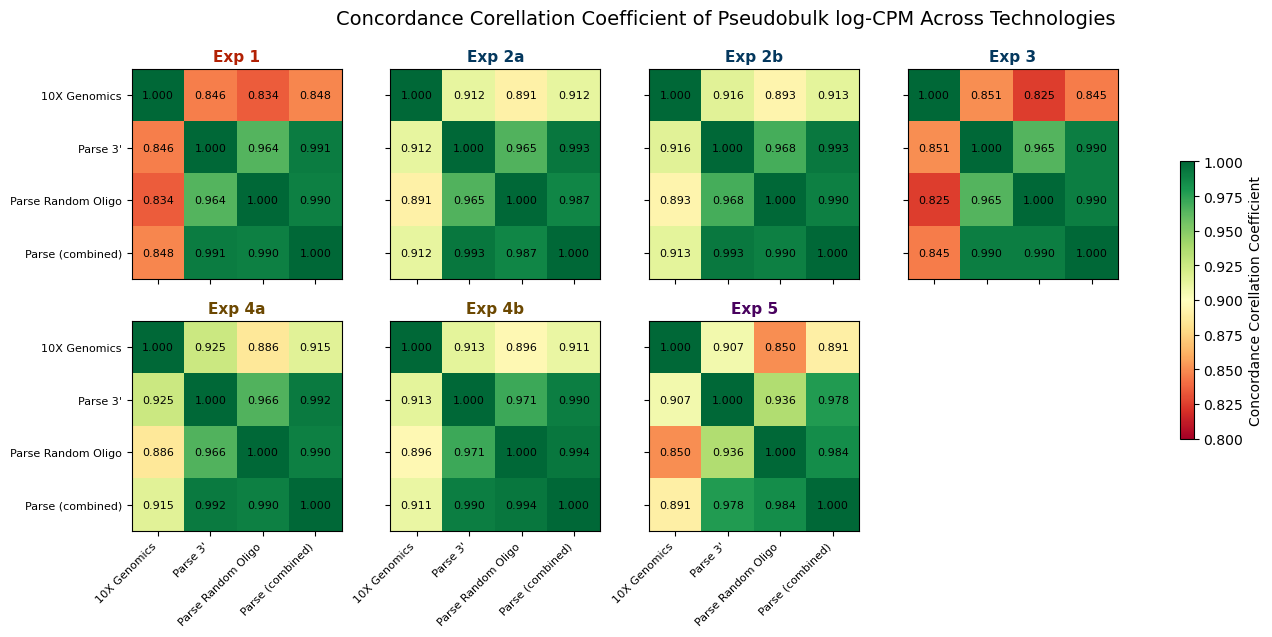

In [13]:
from scipy.stats import spearmanr

# Options: 'pearson', 'spearman', 'ccc'
CORR_METHOD = 'Concordance Corellation Coefficient'

def compute_correlation(x, y, method):
    if method == 'Pearson Correlation':
        return np.corrcoef(x, y)[0, 1]
    elif method == 'Spearman Correlation':
        return spearmanr(x, y).correlation
    elif method == 'Concordance Corellation Coefficient':
        mean_x, mean_y = np.mean(x), np.mean(y)
        var_x, var_y = np.var(x), np.var(y)
        r = np.corrcoef(x, y)[0, 1]
        return 2 * r * np.sqrt(var_x) * np.sqrt(var_y) / (var_x + var_y + (mean_x - mean_y)**2)

# Compute all correlation matrices
corr_matrices = {}
for s in SAMPLES:
    pb = pseudobulk_data[s['label']]
    common_genes = sorted(set.intersection(*[set(pb[t].index) for t in TECHS]))
    matrix = np.ones((len(TECHS), len(TECHS)))
    for i, t1 in enumerate(TECHS):
        for j, t2 in enumerate(TECHS):
            if i != j:
                x = pb[t1].loc[common_genes].values
                y = pb[t2].loc[common_genes].values
                matrix[i, j] = compute_correlation(x, y, CORR_METHOD)
    corr_matrices[s['label']] = matrix

# Global color scale
all_off_diag = [m[i, j] for m in corr_matrices.values() for i in range(4) for j in range(4) if i != j]
vmin = np.floor(min(all_off_diag) * 20) / 20

n_cols = 4
n_rows = (len(SAMPLES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_2d(axes)

for idx, s in enumerate(SAMPLES):
    ax = axes[idx // n_cols, idx % n_cols]
    matrix = corr_matrices[s['label']]

    im = ax.imshow(matrix, vmin=vmin, vmax=1.0, cmap='RdYlGn', aspect='equal')

    ax.set_xticks(range(len(TECHS)))
    ax.set_yticks(range(len(TECHS)))
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_title(s['label'], fontsize=11, fontweight='bold',
                 color=TISSUE_COLORS[s['tissue']])

    if idx // n_cols == n_rows - 1 or idx == len(SAMPLES) - 1:
        ax.set_xticklabels(TECH_LABELS.values(), fontsize=8, rotation=45, ha='right')

    for i in range(len(TECHS)):
        for j in range(len(TECHS)):
            ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center', fontsize=8,
                    color='black')

for i in range(n_rows):
    axes[i, 0].set_yticks(range(len(TECHS)))
    axes[i, 0].set_yticklabels(TECH_LABELS.values(), fontsize=8)

for idx in range(len(SAMPLES), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.colorbar(im, ax=axes, shrink=0.6, label=CORR_METHOD)
fig.suptitle(f'{CORR_METHOD} of Pseudobulk log-CPM Across Technologies', fontsize=14)
plt.show()

In [ ]:
GENES_OF_INTEREST = ['HBB', 'HBA1', 'HBA2']
PBMC_SAMPLES = [s for s in SAMPLES if s['tissue'] == 'PBMC']

# Knee-plot cutoffs come from Config/notebooks.yaml (single source of truth),
# keyed by (analysis, variant): Analysis_2 uses its tenx_type (standard/mini),
# Analysis_3 uses the H1/H2 sample in the assay name, the rest have no variant.
def _variant(s):
    if s['analysis'] == 'Analysis_2':
        return s['tenx_type']
    if s['analysis'] == 'Analysis_3':
        return s['parse_assay'].rsplit('_', 1)[-1]
    return None

for _s in SAMPLES:
    _ctx = processing.notebook_context(_s['analysis'], _variant(_s))
    _s['cutoffs'] = {t: _ctx.knee('sampled', [t])[0] for t in TECHS}


In [15]:
# gene_count_data was populated during the main loading loop (genes_to_track=GENES_TO_TRACK).
# No second loading pass needed — all pre- and post-filter counts are already in memory.
print("Gene count data available for:", list(gene_count_data.keys()))

Gene count data available for: ['Exp 1', 'Exp 2a', 'Exp 2b', 'Exp 3', 'Exp 4a', 'Exp 4b', 'Exp 5']


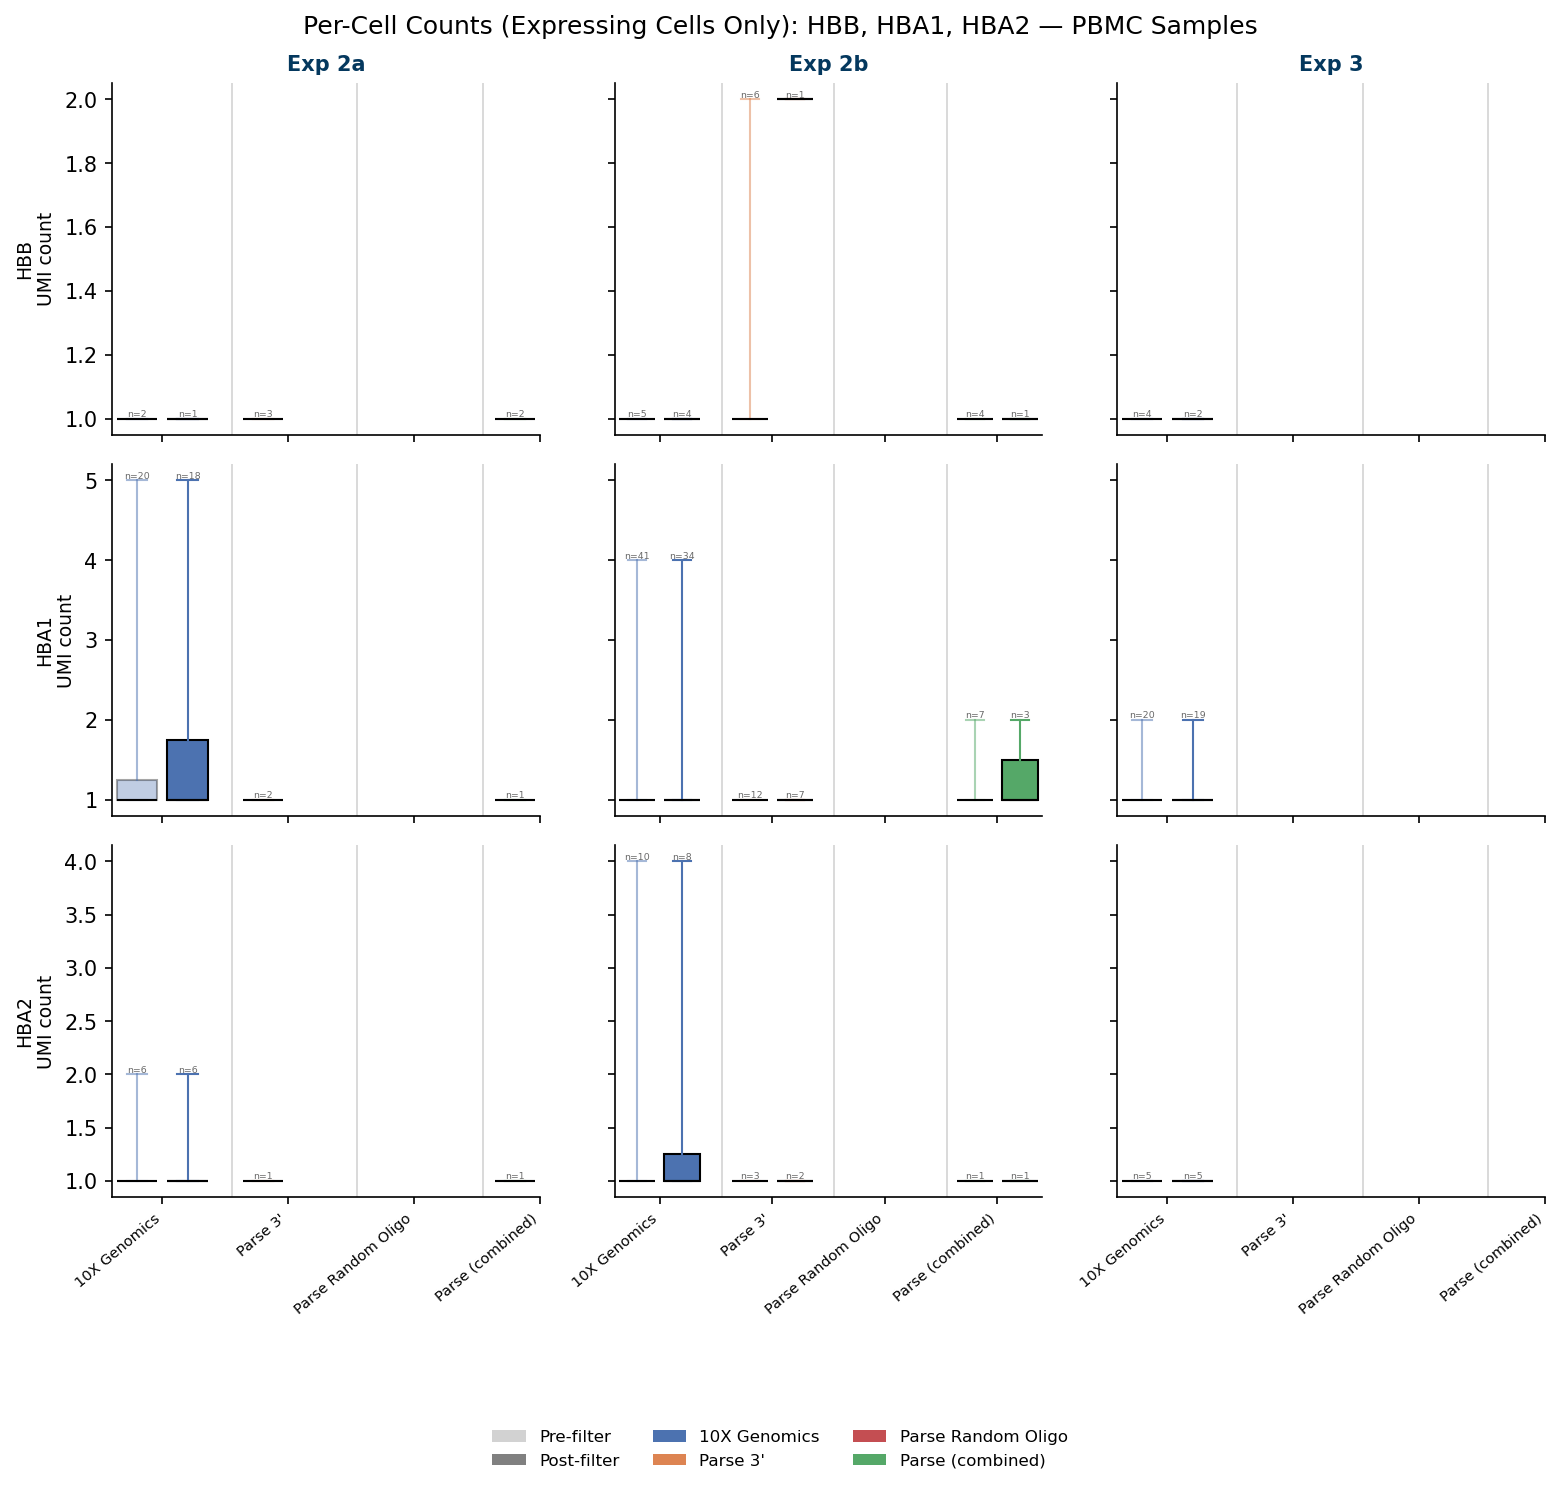

Pre Total UMI  Post Total UMI  \
Experiment Technology         Gene                                  
Exp 2a     10X Genomics       HBB               2               1   
                              HBA1             29              27   
                              HBA2              7               7   
           Parse 3'           HBB               3               0   
                              HBA1              2               0   
                              HBA2              1               0   
           Parse Random Oligo HBB               0               0   
                              HBA1              0               0   
                              HBA2              0               0   
           Parse (combined)   HBB               2               0   
                              HBA1              1               0   
                              HBA2              1               0   
Exp 2b     10X Genomics       HBB               5               4   
                              HBA1             53              46   
                              HBA2             14              12   
           Parse 3'           HBB               7               2   
                              HBA1             12               7   
                              HBA2              3               2   
           Parse Random Oligo HBB               0               0   
                              HBA1              0               0   
                              HBA2              0               0   
           Parse (combined)   HBB               4               1   
                              HBA1              8               4   
                              HBA2              1               1   
Exp 3      10X Genomics       HBB               4               2   
                              HBA1             21              20   
                              HBA2              5               5   
           Parse 3'           HBB               0               0   
                              HBA1              0               0   
                              HBA2              0               0   
           Parse Random Oligo HBB               0               0   
                              HBA1              0               0   
                              HBA2              0               0   
           Parse (combined)   HBB               0               0   
                              HBA1              0               0   
                              HBA2              0               0   

                                    Pre Nonzero Cells  Post Nonzero Cells  \
Experiment Technology         Gene                                          
Exp 2a     10X Genomics       HBB                   2                   1   
                              HBA1                 20                  18   
                              HBA2                  6                   6   
           Parse 3'           HBB                   3                   0   
                              HBA1                  2                   0   
                              HBA2                  1                   0   
           Parse Random Oligo HBB                   0                   0   
                              HBA1                  0                   0   
                              HBA2                  0                   0   
           Parse (combined)   HBB                   2                   0   
                              HBA1                  1                   0   
                              HBA2                  1                   0   
Exp 2b     10X Genomics       HBB                   5                   4   
                              HBA1                 41                  34   
                              HBA2                 10                   8   
           Parse 3'           HBB                   6                   1   
                           

In [16]:
n_genes = len(GENES_OF_INTEREST)
n_pbmc  = len(PBMC_SAMPLES)
group_w = 2.5

fig, axes = plt.subplots(
    n_genes, n_pbmc,
    figsize=(3.5 * n_pbmc, 3.2 * n_genes),
    sharey='row', dpi=150,
)
axes = np.atleast_2d(axes)

for g_idx, gene in enumerate(GENES_OF_INTEREST):
    for s_idx, s in enumerate(PBMC_SAMPLES):
        ax = axes[g_idx, s_idx]

        for t_idx, tech in enumerate(TECHS):
            d     = gene_count_data[s['label']][tech][gene]
            color = COLORS[tech]

            for stage_idx, stage in enumerate(['pre', 'post']):
                arr        = d[stage]
                expressing = arr[arr > 0]
                pos        = t_idx * group_w + stage_idx
                alpha      = 0.35 if stage == 'pre' else 1.0

                if len(expressing) == 0:
                    continue

                bp = ax.boxplot(
                    [expressing],
                    positions=[pos],
                    patch_artist=True,
                    whis=(0, 100),
                    widths=0.8,
                    medianprops=dict(color='black', linewidth=1),
                    whiskerprops=dict(color=color, alpha=max(alpha, 0.5)),
                    capprops=dict(color=color, alpha=max(alpha, 0.5)),
                )
                bp['boxes'][0].set_facecolor(color)
                bp['boxes'][0].set_alpha(alpha)

                whisker_top = max(bp['whiskers'][1].get_ydata())
                median_val  = bp['medians'][0].get_ydata()[0]

                # n= and max= stacked above the top whisker cap
                ax.text(pos, whisker_top,
                        f'n={len(expressing)}',
                        ha='center', va='bottom', fontsize=4.5, color='dimgray',
                        linespacing=1.3)

        for t_idx in range(1, len(TECHS)):
            ax.axvline(t_idx * group_w - group_w / 4, color='lightgray', linewidth=0.8, zorder=0)

        centers = [t_idx * group_w + 0.5 for t_idx in range(len(TECHS))]
        ax.set_xticks(centers)
        if g_idx == n_genes - 1:
            ax.set_xticklabels([TECH_LABELS[t] for t in TECHS], rotation=40, ha='right', fontsize=7)
        else:
            ax.set_xticklabels([])

        if g_idx == 0:
            ax.set_title(s['label'], fontsize=10, fontweight='bold',
                         color=TISSUE_COLORS[s['tissue']])
        if s_idx == 0:
            ax.set_ylabel(f'{gene}\nUMI count', fontsize=9)

        ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor='gray', alpha=0.35, label='Pre-filter'),
    mpatches.Patch(facecolor='gray', alpha=1.0,  label='Post-filter'),
] + [mpatches.Patch(facecolor=COLORS[t], label=TECH_LABELS[t]) for t in TECHS]

fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Per-Cell Counts (Expressing Cells Only): {", ".join(GENES_OF_INTEREST)} — PBMC Samples',
    fontsize=12,
)
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# Summary table
rows = []
for s in PBMC_SAMPLES:
    for tech in TECHS:
        for gene in GENES_OF_INTEREST:
            d = gene_count_data[s['label']][tech][gene]
            pre_pos  = d['pre'][d['pre'] > 0]
            post_pos = d['post'][d['post'] > 0]
            rows.append({
                'Experiment':         s['label'],
                'Technology':         TECH_LABELS[tech],
                'Gene':               gene,
                'Pre Total UMI':      int(d['pre'].sum()),
                'Post Total UMI':     int(d['post'].sum()),
                'Pre Nonzero Cells':  int(len(pre_pos)),
                'Post Nonzero Cells': int(len(post_pos)),
                'Pre Max':            int(pre_pos.max())  if len(pre_pos)  else 0,
                'Post Max':           int(post_pos.max()) if len(post_pos) else 0,
                'Pre Median':         int(np.median(pre_pos))  if len(pre_pos)  else 0,
                'Post Median':        int(np.median(post_pos)) if len(post_pos) else 0,
            })

table_df = pd.DataFrame(rows).set_index(['Experiment', 'Technology', 'Gene'])
display(table_df)